In [23]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# import sys
# !{sys.executable} -m pip install seaborn


# print(sns.__version__)



In [24]:
COLSPECS = [
    # --- Administrative / Record Identifiers ---
    ("data_year",               0,   1,  "str"),
    ("shipment_number",         1,   3,  "str"),
    ("reporting_area",          3,   4,  "str"),
    ("certificate_number",      4,  10,  "str"),
    ("record_type",            10,  11,  "str"),
    ("resident_status",        11,  12,  "str"),

    # --- Place of Residence ---
    ("res_state",              12,  14,  "str"),
    ("res_county",             14,  17,  "str"),
    ("res_city",               17,  20,  "str"),
    ("res_pop_size",           20,  21,  "str"),
    ("res_smsa",               21,  24,  "str"),
    ("res_metro_flag",         24,  25,  "str"),
    ("res_division_subcode",   25,  27,  "str"),

    # --- Place of Occurrence ---
    ("occ_state",              27,  29,  "str"),
    ("occ_county",             29,  32,  "str"),
    ("occ_division_subcode",   32,  34,  "str"),

    # --- Child Characteristics ---
    ("sex",                    34,  35,  "str"),
    ("attendant",              35,  36,  "str"),
    ("race_father_detail",     36,  37,  "str"),
    ("race_mother_detail",     37,  38,  "str"),
    ("race_child_detail",      38,  39,  "str"),
    ("race_child_recode3",     39,  40,  "str"),

    # --- Mother's Age ---
    ("mother_age_detail",      40,  42,  "str"),
    ("mother_age_recode36",    42,  44,  "str"),
    ("mother_age_recode15",    44,  46,  "str"),
    ("mother_age_recode12",    46,  48,  "str"),
    ("mother_age_recode8",     48,  49,  "str"),
    ("mother_age_recode7",     49,  50,  "str"),
    ("mother_age_recode6",     50,  51,  "str"),

    # --- Birth Order / Parity ---
    ("children_alive_now",     51,  53,  "str"),
    ("children_dead",          53,  55,  "str"),
    ("children_fetal_deaths",  55,  57,  "str"),
    ("birth_order_total",      57,  59,  "str"),
    ("birth_order_recode9",    59,  60,  "str"),
    ("live_birth_order_detail",60,  62,  "str"),
    ("live_birth_order_r9",    62,  63,  "str"),
    ("live_birth_order_r8",    63,  64,  "str"),
    ("live_birth_order_r7",    64,  65,  "str"),
    ("live_birth_order_r6",    65,  66,  "str"),
    ("live_birth_order_r3",    66,  67,  "str"),
    ("combo_flag_77",          67,  68,  "str"),

    # --- Father's Age ---
    ("father_age_detail",      68,  70,  "str"),
    ("father_age_recode11",    70,  72,  "str"),

    # --- Birthweight ---
    ("birthweight_grams",      72,  76,  "str"),
    ("birthweight_recode12",   76,  78,  "str"),
    ("birthweight_recode3",    78,  79,  "str"),
    ("blank_80",               79,  80,  "str"),

    # --- Plurality (BLANK for 1969) ---
    ("plurality_detail",       80,  81,  "str"),
    ("plurality_recode3",      81,  82,  "str"),
    ("plurality_recode2",      82,  83,  "str"),

    # --- Birth Date ---
    ("birth_month",            83,  85,  "str"),
    ("birth_day",              85,  87,  "str"),

    # --- LMP ---
    ("lmp_month",              87,  89,  "str"),
    ("lmp_day",                89,  91,  "str"),
    ("lmp_year",               91,  92,  "str"),

    # --- Gestation ---
    ("gestation_weeks",        92,  94,  "str"),
    ("gestation_recode10",     94,  96,  "str"),
    ("gestation_recode3",      96,  97,  "str"),

    # --- Mother's Education ---
    ("mother_edu_detail",      97,  99,  "str"),
    ("mother_edu_recode14",    99, 101,  "str"),
    ("mother_edu_recode6",    101, 102,  "str"),

    # --- Father's Education ---
    ("father_edu_detail",     102, 104,  "str"),
    ("father_edu_recode14",   104, 106,  "str"),

    # --- Legitimacy ---
    ("legitimacy_detail",     106, 107,  "str"),
    ("legitimacy_recode3",    107, 108,  "str"),

    # --- Prenatal Care ---
    ("prenatal_month_detail", 108, 109,  "str"),
    ("prenatal_recode10",     109, 111,  "str"),
    ("prenatal_recode6",      111, 112,  "str"),

    # --- Last Live Birth ---
    ("last_livebirth_month",  112, 114,  "str"),
    ("last_livebirth_year",   114, 116,  "str"),
    ("interval_livebirth_mo", 116, 119,  "str"),
    ("interval_lb_recode17",  119, 121,  "str"),
    ("interval_lb_recode10",  121, 123,  "str"),
    ("interval_lb_recode8",   123, 124,  "str"),

    # --- Last Fetal Death ---
    ("last_fetaldeath_month", 124, 126,  "str"),
    ("last_fetaldeath_year",  126, 128,  "str"),
    ("fetal_death_date_flag", 128, 129,  "str"),
    ("interval_fd_detail",    129, 132,  "str"),
    ("interval_lastpreg_mo",  132, 135,  "str"),
    ("interval_lastpreg_r9",  135, 136,  "str"),
    ("outcome_last_preg",     136, 137,  "str"),

    # --- Mother's Place of Birth (BLANK for 1969) ---
    ("mother_pob",            137, 139,  "str"),

    # --- Blank / Reserved ---
    ("blank_140_141",         139, 141,  "str"),
    ("congenital_malform",    141, 142,  "str"),
    ("reserved_143_145",      142, 145,  "str"),

    # --- State Reporting Flags (Residence) ---
    ("flag_res_legitimacy",   145, 146,  "str"),
    ("flag_res_education",    146, 147,  "str"),
    ("flag_res_lmp",          147, 148,  "str"),
    ("flag_res_prenatal",     148, 149,  "str"),
    ("flag_res_last_lb",      149, 150,  "str"),
    ("flag_res_last_fd",      150, 151,  "str"),
    ("flag_smsa_legitimacy",  151, 152,  "str"),
    ("flag_smsa_education",   152, 153,  "str"),
    ("flag_res_cong_malform", 153, 154,  "str"),
    ("reserved_155_160",      154, 160,  "str"),

    # --- State Reporting Flags (Occurrence) ---
    ("flag_occ_legitimacy",   160, 161,  "str"),
    ("flag_occ_education",    161, 162,  "str"),
    ("flag_occ_lmp",          162, 163,  "str"),
    ("flag_occ_prenatal",     163, 164,  "str"),
    ("flag_occ_last_lb",      164, 165,  "str"),
    ("flag_occ_last_fd",      165, 166,  "str"),
    ("flag_occ_cong_malform", 166, 167,  "str"),
    ("reserved_168_215",      167, 215,  "str"),
]

In [25]:
NUMERIC_COLS = {
    "mother_age_detail":       {"na_values": {"99"},                "dtype": "Int8"},
    "father_age_detail":       {"na_values": {"99"},                "dtype": "Int8"},
    "birthweight_grams":       {"na_values": {"9999"},              "dtype": "Int16"},
    "birth_month":             {"na_values": set(),                 "dtype": "Int8"},
    "birth_day":               {"na_values": {"99"},                "dtype": "Int8"},
    "gestation_weeks":         {"na_values": {"00", "99"},          "dtype": "Int8"},
    "birth_order_total":       {"na_values": {"99"},                "dtype": "Int8"},
    "live_birth_order_detail": {"na_values": {"99"},                "dtype": "Int8"},
    "children_alive_now":      {"na_values": {"55","66","77","99"}, "dtype": "Int8"},
    "children_dead":           {"na_values": {"55","66","77","99"}, "dtype": "Int8"},
    "mother_edu_detail":       {"na_values": {"66","77","88","99"}, "dtype": "Int8"},
    "father_edu_detail":       {"na_values": {"66","77","88","99"}, "dtype": "Int8"},
}

LABELS = {
    "data_year":      {"9": 1969, "0": 1970, "1": 1971},
    "record_type":    {"1": "Resident", "2": "Nonresident"},
    "resident_status":{"1": "Resident", "2": "Intrastate NR", "3": "Interstate NR", "4": "Foreign"},
    "sex":            {"1": "Male", "2": "Female"},
    "attendant":      {"1": "Physician/Hospital", "2": "Physician/Home", "3": "Midwife", "4": "Other"},
    "race_mother_detail": {
        "0": "Guamian", "1": "White", "2": "Negro", "3": "Indian",
        "4": "Chinese", "5": "Japanese", "6": "Hawaiian", "7": "Other",
        "8": "Filipino", "9": "Unknown"
    },
    "race_child_recode3":  {"1": "White", "2": "Other", "3": "Negro"},
    "birthweight_recode3": {"1": "<=2500g", "2": ">2500g", "3": "Unknown"},
    "legitimacy_detail":   {"1": "Legitimate", "2": "Illegitimate", "8": "Not reported", "9": "Unknown"},
    "outcome_last_preg":   {"0": "N/A", "1": "Live Birth", "2": "Fetal Death", "3": "Unknown"},
    "congenital_malform":  {"0": "None stated", "1": "Any stated", "8": "Not on cert"},
}

In [26]:
def parse_nchs1969(
    filepath="Data/Data_ NCHS /US1969/US1969.dat",
    nrows=None,
    apply_labels=False
):
    colspecs  = [(s, e) for _, s, e, _ in COLSPECS]
    col_names = [n      for n, _, _, _ in COLSPECS]

    df = pd.read_fwf(
        filepath_or_buffer=filepath,
        colspecs=colspecs,
        names=col_names,
        dtype=str,
        encoding="cp1252",
        header=None,
        nrows=nrows,
        na_filter=False,
    )

    # Cast numerics with proper NA handling
    for col, spec in NUMERIC_COLS.items():
        if col not in df.columns:
            continue
        ser = df[col].str.strip()
        ser = ser.where(~ser.isin(spec["na_values"]), other=pd.NA)
        df[col] = pd.to_numeric(ser, errors="coerce").astype(spec["dtype"])

    # Strip whitespace from all string columns
    str_cols = df.select_dtypes("object").columns
    df[str_cols] = df[str_cols].apply(lambda s: s.str.strip())

    # Decode data_year
    df["data_year"] = df["data_year"].map(LABELS["data_year"]).fillna(df["data_year"])

    # Optionally decode categoricals to human-readable labels
    if apply_labels:
        for col, mapping in LABELS.items():
            if col in df.columns and col != "data_year":
                df[col] = df[col].map(mapping).fillna(df[col])

    return df

In [27]:
# Full load — may take a few minutes (~1.8M rows)
df = parse_nchs1969()

# ---- OR test with a sample first ----
# df = parse_nchs1969(nrows=100_000)

# ---- OR with human-readable labels ----
# df = parse_nchs1969(apply_labels=True)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

/var/folders/m2/16rtrgqx6lgc0m6klf3rlbh00000gn/T/ipykernel_1509/434469417.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes("object").columns


Loaded: 1,800,103 rows × 103 columns


,data_year,shipment_number,reporting_area,certificate_number,record_type,resident_status,res_state,res_county,res_city,res_pop_size,...,flag_res_cong_malform,reserved_155_160,flag_occ_legitimacy,flag_occ_education,flag_occ_lmp,flag_occ_prenatal,flag_occ_last_lb,flag_occ_last_fd,flag_occ_cong_malform,reserved_168_215
0,1969,01,0,,1,1,01,001,999,9,...,1,000000,1,0,0,0,0,0,1,00000 2
1,1969,01,0,,2,2,01,026,999,9,...,1,000000,1,0,0,0,0,0,1,00000 1
2,1969,01,0,,1,1,01,001,999,9,...,1,000000,1,0,0,0,0,0,1,00000 1
3,1969,01,0,,1,1,01,001,999,9,...,1,000000,1,0,0,0,0,0,1,00000 1
4,1969,01,0,,1,1,01,001,999,9,...,1,000000,1,0,0,0,0,0,1,00000 2


In [28]:
print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nRecord types :\n{df['record_type'].value_counts()}")
print(f"\nSex          :\n{df['sex'].value_counts()}")
print(f"\nBirthweight  :\n{df['birthweight_grams'].describe()}")
print(f"\nMother age   :\n{df['mother_age_detail'].describe()}")
print(f"\nBirth month  :\n{df['birth_month'].value_counts().sort_index()}")
print(f"\nAttendant    :\n{df['attendant'].value_counts()}")

Memory usage : 8307.5 MB

Record types :
record_type
1    1470635
2     329468
Name: count, dtype: int64

Sex          :
sex
1    923286
2    876817
Name: count, dtype: int64

Birthweight  :
count      1790014.0
mean     3267.311556
std       590.767921
min            227.0
25%           2948.0
50%           3289.0
75%           3629.0
max           8165.0
Name: birthweight_grams, dtype: Float64

Mother age   :
count    1800103.0
mean     24.736761
std       5.640532
min           10.0
25%           21.0
50%           24.0
75%           28.0
max           49.0
Name: mother_age_detail, dtype: Float64

Birth month  :
birth_month
1     146970
2     135393
3     148275
4     141319
5     144562
6     145805
7     159178
8     160517
9     156310
10    155986
11    148527
12    157261
Name: count, dtype: Int64

Attendant    :
attendant
1    1783130
3      11512
2       3760
4       1701
Name: count, dtype: int64


In [29]:
df.columns.tolist()

['data_year',
 'shipment_number',
 'reporting_area',
 'certificate_number',
 'record_type',
 'resident_status',
 'res_state',
 'res_county',
 'res_city',
 'res_pop_size',
 'res_smsa',
 'res_metro_flag',
 'res_division_subcode',
 'occ_state',
 'occ_county',
 'occ_division_subcode',
 'sex',
 'attendant',
 'race_father_detail',
 'race_mother_detail',
 'race_child_detail',
 'race_child_recode3',
 'mother_age_detail',
 'mother_age_recode36',
 'mother_age_recode15',
 'mother_age_recode12',
 'mother_age_recode8',
 'mother_age_recode7',
 'mother_age_recode6',
 'children_alive_now',
 'children_dead',
 'children_fetal_deaths',
 'birth_order_total',
 'birth_order_recode9',
 'live_birth_order_detail',
 'live_birth_order_r9',
 'live_birth_order_r8',
 'live_birth_order_r7',
 'live_birth_order_r6',
 'live_birth_order_r3',
 'combo_flag_77',
 'father_age_detail',
 'father_age_recode11',
 'birthweight_grams',
 'birthweight_recode12',
 'birthweight_recode3',
 'blank_80',
 'plurality_detail',
 'plurality_

In [30]:
data_year_1969 = df[df["data_year"] == 1969]
data_year_1969.info()
data_year_1969.head(5)


<class 'pandas.DataFrame'>
RangeIndex: 1800103 entries, 0 to 1800102
Columns: 103 entries, data_year to reserved_168_215
dtypes: Int16(1), Int8(11), int64(1), str(90)
memory usage: 1.3 GB


,data_year,shipment_number,reporting_area,certificate_number,record_type,resident_status,res_state,res_county,res_city,res_pop_size,...,flag_res_cong_malform,reserved_155_160,flag_occ_legitimacy,flag_occ_education,flag_occ_lmp,flag_occ_prenatal,flag_occ_last_lb,flag_occ_last_fd,flag_occ_cong_malform,reserved_168_215
0,1969,01,0,,1,1,01,001,999,9,...,1,000000,1,0,0,0,0,0,1,00000 2
1,1969,01,0,,2,2,01,026,999,9,...,1,000000,1,0,0,0,0,0,1,00000 1
2,1969,01,0,,1,1,01,001,999,9,...,1,000000,1,0,0,0,0,0,1,00000 1
3,1969,01,0,,1,1,01,001,999,9,...,1,000000,1,0,0,0,0,0,1,00000 1
4,1969,01,0,,1,1,01,001,999,9,...,1,000000,1,0,0,0,0,0,1,00000 2


In [31]:
print(df["res_division_subcode"].dtype)


str


In [32]:
#sorted(df["res_division_subcode"].unique()) Texas is the sate of west south central division (7) and subcode 4
texas = df[df["res_division_subcode"] == "74"]
texas.info()

<class 'pandas.DataFrame'>
Index: 113310 entries, 1752 to 1799690
Columns: 103 entries, data_year to reserved_168_215
dtypes: Int16(1), Int8(11), int64(1), str(90)
memory usage: 82.2 MB


In [33]:
texas.head(5)

,data_year,shipment_number,reporting_area,certificate_number,record_type,resident_status,res_state,res_county,res_city,res_pop_size,...,flag_res_cong_malform,reserved_155_160,flag_occ_legitimacy,flag_occ_education,flag_occ_lmp,flag_occ_prenatal,flag_occ_last_lb,flag_occ_last_fd,flag_occ_cong_malform,reserved_168_215
1752,1969,01,0,,2,3,44,074,999,9,...,1,000000,1,0,0,0,0,0,1,00000 1
1773,1969,01,0,,2,3,44,051,999,9,...,1,000000,1,0,0,0,0,0,1,00000 1
6543,1969,03,0,,2,3,44,161,999,9,...,1,000000,1,0,0,0,0,0,1,00000 1
6633,1969,03,0,,2,3,44,057,999,9,...,1,000000,1,0,0,0,0,0,1,00000 1
9010,1969,04,0,,2,3,44,014,999,9,...,1,000000,1,0,0,0,0,0,1,00000 2


In [34]:
selected_texas = texas[["data_year", "res_division_subcode", "res_state", "occ_state", "children_alive_now"]]

selected_texas.head(5)

,data_year,res_division_subcode,res_state,occ_state,children_alive_now
1752,1969,74,44,01,0
1773,1969,74,44,01,1
6543,1969,74,44,01,3
6633,1969,74,44,01,1
9010,1969,74,44,01,1


In [35]:
import pandas as pd

# Calculate raw counts and percentages
counts = selected_texas['children_alive_now'].value_counts(dropna=False)
percent = selected_texas['children_alive_now'].value_counts(dropna=False, normalize=True) * 100

# Combine into a final summary table
freq_table = pd.DataFrame({'Frequency': counts, 'Percentage (%)': percent})

# Add a total row at the bottom
freq_table.loc['Total'] = [freq_table['Frequency'].sum(), freq_table['Percentage (%)'].sum()]

# Ensure frequency column stays as whole numbers
freq_table['Frequency'] = freq_table['Frequency'].astype(int)

print(freq_table)


                    Frequency  Percentage (%)
children_alive_now                           
0                       43786       38.642662
1                       30109       26.572235
2                       16945       14.954549
3                        9138        8.064602
4                        5081        4.484159
5                        3013        2.659077
6                        1858        1.639749
7                        1236        1.090813
8                         834        0.736034
9                         504        0.444797
10                        345        0.304474
11                        189        0.166799
12                        117        0.103257
13                         47        0.041479
<NA>                       39        0.034419
14                         32        0.028241
15                         15        0.013238
16                          9        0.007943
20                          5        0.004413
17                          3     

In [36]:
#Filter: mother RESIDES in Texas AND birth OCCURRED in Texas
texas_births = df[
    (df["data_year"] == 1969) &
    (df["res_state"] == "44") &
    (df["occ_state"] == "44")
]

print(f"Live births in Texas from Texas-resident mothers: {len(texas_births):,}")

Live births in Texas from Texas-resident mothers: 112,565


In [37]:
print(df["res_state"].dtype)
print(df["occ_state"].dtype)

str
str


In [38]:
# --- Clean and label the two variables ---

edu_labels = {
    0:  "0 (No school)",
    1:  "1st grade",
    2:  "2nd grade",
    3:  "3rd grade",
    4:  "4th grade",
    5:  "5th grade",
    6:  "6th grade",
    7:  "7th grade",
    8:  "8th grade",
    9:  "1yr HS",
    10: "2yr HS",
    11: "3yr HS",
    12: "4yr HS",
    13: "1yr College",
    14: "2yr College",
    15: "3yr College",
    16: "4yr College",
    17: "5yr+ College",
}

edu_years_labels = {i: "0-8 years elementary school" for i in range(0, 9)}

order_labels = {
    1: "1st",
    2: "2nd",
    3: "3rd",
    4: "4th",
    5: "5th",
    6: "6th",
    7: "7th",
    8: "8th+",
}

# Work on a clean subset — drop unknowns in both columns
edu_order = df[
    df["mother_edu_detail"].notna() &
    df["birth_order_total"].notna()
][["mother_edu_detail", "birth_order_total"]].copy()

# Cap birth order at 8+ for readability
edu_order["birth_order_grp"] = edu_order["birth_order_total"].clip(upper=8)
edu_order["birth_order_grp"] = edu_order["birth_order_grp"].map(order_labels)

# Map education
edu_order["edu_label"] = edu_order["mother_edu_detail"].map(edu_labels)

print(f"Records with both variables: {len(edu_order):,}")
edu_order.head()

Records with both variables: 1,100,442


,mother_edu_detail,birth_order_total,birth_order_grp,edu_label
32056,12,2,2nd,4yr HS
32057,15,1,1st,3yr College
32058,13,3,3rd,1yr College
32059,12,2,2nd,4yr HS
32060,12,4,4th,4yr HS


In [39]:
# ============================================================
#  Grouped bar: Education level → Birth order distribution
# ============================================================

# --- Rebuild pivot if needed ---
edu_order = edu_order[
    edu_order["mother_edu_detail"].notna() &
    edu_order["birth_order_total"].notna()
][["mother_edu_detail", "birth_order_total"]].copy()

edu_order["birth_order_grp"] = edu_order["birth_order_total"].clip(upper=8)

order_labels = {1: "1st", 2: "2nd", 3: "3rd", 4: "4th",
                5: "5th", 6: "6th", 7: "7th", 8: "8th+"}
edu_labels   = {
    0: "0 (No school)", 1: "1st grade",  2: "2nd grade",  3: "3rd grade",
    4: "4th grade",     5: "5th grade",  6: "6th grade",  7: "7th grade",
    8: "8th grade",     9: "1yr HS",    10: "2yr HS",    11: "3yr HS",
   12: "4yr HS",       13: "1yr College",14: "2yr College",15: "3yr College",
   16: "4yr College",  17: "5yr+ College",
}
edu_years_labels = {i: "0-8 years elementary school" for i in range(0, 9)}

edu_order["birth_order_grp"] = edu_order["birth_order_grp"].map(order_labels)
edu_order["edu_label"] = edu_order["mother_edu_detail"].map(edu_labels)
edu_order["edu_years_label"] = edu_order["mother_edu_detail"].map(edu_years_labels)
edu_order["edu_years_label"] = edu_order["edu_years_label"].fillna(edu_order["edu_label"])

order_cols = ["1st","2nd","3rd","4th","5th","6th","7th","8th+"]

pivot_full = pd.crosstab(
    edu_order["edu_label"],
    edu_order["birth_order_grp"],
    normalize="index"
).mul(100).round(2)

pivot_compact = pd.crosstab(
    edu_order["edu_years_label"],
    edu_order["birth_order_grp"],
    normalize="index"
).mul(100).round(2)

edu_label_order = [
    "0 (No school)", "1st grade", "2nd grade", "3rd grade", "4th grade",
    "5th grade", "6th grade", "7th grade", "8th grade",
    "1yr HS", "2yr HS", "3yr HS", "4yr HS",
    "1yr College", "2yr College", "3yr College", "4yr College", "5yr+ College",
]

compact_order = [
    "0-8 years elementary school",
    "1yr HS", "2yr HS", "3yr HS", "4yr HS",
    "1yr College", "2yr College", "3yr College", "4yr College", "5yr+ College",
]

pivot_full = pivot_full.reindex(edu_label_order).dropna(how="all")
pivot_full = pivot_full[[c for c in order_cols if c in pivot_full.columns]]
pivot_compact = pivot_compact.reindex(compact_order).dropna(how="all")
pivot_compact = pivot_compact[[c for c in order_cols if c in pivot_compact.columns]]

# --- Frequency tables for each label set ---
freq_full = (
    edu_order["edu_label"]
    .value_counts(dropna=False)
    .rename_axis("education")
    .reset_index(name="Frequency")
)
freq_full["Percentage"] = (freq_full["Frequency"] / freq_full["Frequency"].sum() * 100).round(2)
freq_full = freq_full.set_index("education").reindex(edu_label_order).dropna(how="all").reset_index()

freq_compact = (
    edu_order["edu_years_label"]
    .value_counts(dropna=False)
    .rename_axis("education")
    .reset_index(name="Frequency")
)
freq_compact["Percentage"] = (freq_compact["Frequency"] / freq_compact["Frequency"].sum() * 100).round(2)
freq_compact = freq_compact.set_index("education").reindex(compact_order).dropna(how="all").reset_index()

print("Frequency Table — Existing Mother's Education Labels")
display(freq_full)

print("Frequency Table — Combined Elementary School Label")
display(freq_compact)


Frequency Table — Existing Mother's Education Labels


,education,Frequency,Percentage
0,0 (No school),1122,0.10
1,1st grade,457,0.04
2,2nd grade,883,0.08
3,3rd grade,1965,0.18
4,4th grade,3153,0.29
5,5th grade,4470,0.41
6,6th grade,8693,0.79
7,7th grade,14415,1.31
8,8th grade,53002,4.82
9,1yr HS,59338,5.39


Frequency Table — Combined Elementary School Label


,education,Frequency,Percentage
0,0-8 years elementary school,88160,8.01
1,1yr HS,59338,5.39
2,2yr HS,96755,8.79
3,3yr HS,102731,9.34
4,4yr HS,515393,46.84
5,1yr College,65532,5.96
6,2yr College,51214,4.65
7,3yr College,28012,2.55
8,4yr College,74857,6.80
9,5yr+ College,18450,1.68


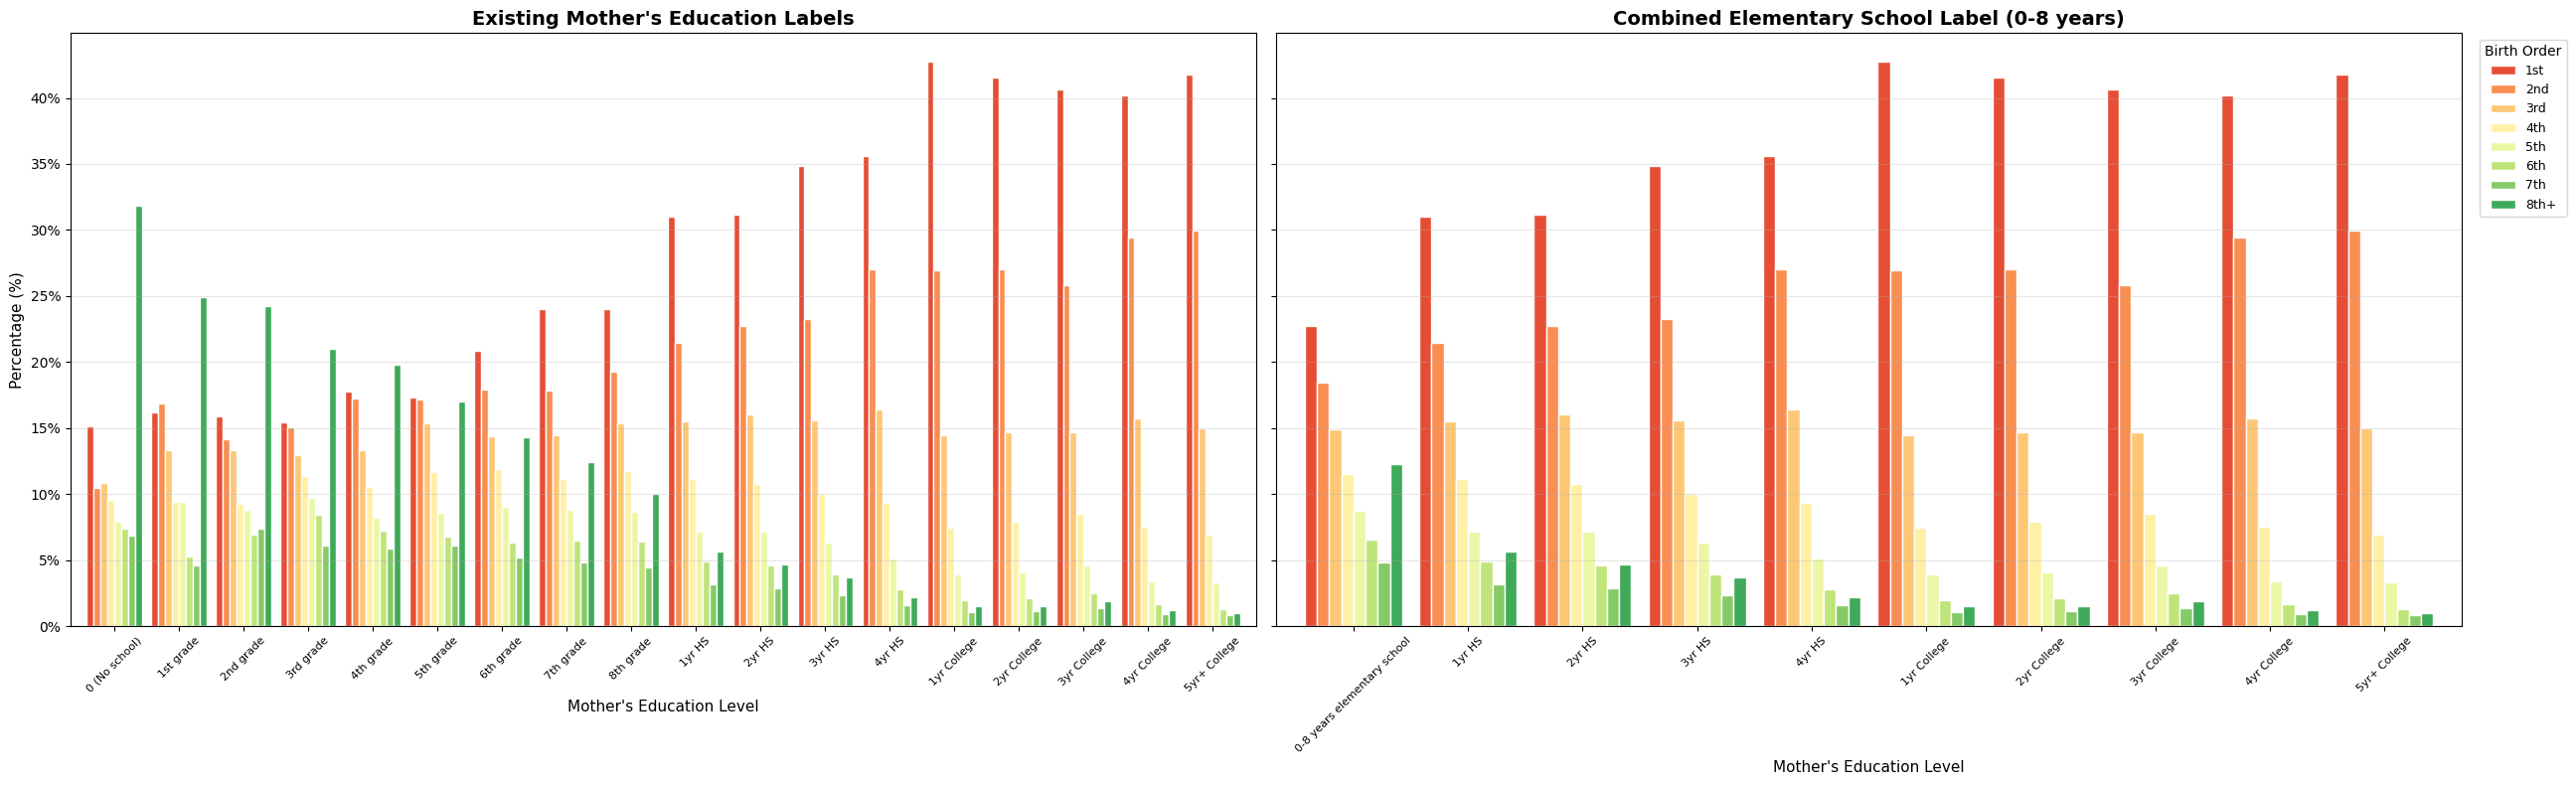

In [40]:
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(order_cols)))

fig, axes = plt.subplots(1, 2, figsize=(26, 8), sharey=True)

pivot_full.plot(
    kind      = "bar",
    stacked   = False,
    ax        = axes[0],
    color     = colors,
    edgecolor = "white",
    width     = 0.85,
    legend    = False,
)
axes[0].set_title("Existing Mother's Education Labels", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Mother's Education Level", fontsize=11)
axes[0].set_ylabel("Percentage (%)", fontsize=11)
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[0].grid(axis="y", alpha=0.3)

pivot_compact.plot(
    kind      = "bar",
    stacked   = False,
    ax        = axes[1],
    color     = colors,
    edgecolor = "white",
    width     = 0.85,
)
axes[1].set_title("Combined Elementary School Label (0-8 years)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Mother's Education Level", fontsize=11)
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(title="Birth Order", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("edu_vs_birthorder_grouped_comparison.png", dpi=150, bbox_inches="tight")
plt.show()